# Random Forest Model Implementation on BookMeas Dataset

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
base_path = r"..\..\data\Final Datasets"
bookmeas_dataset = os.path.join(base_path, "merged_cleaned_balanced_15k.parquet")

In [3]:
df_bo_me = pd.read_parquet(bookmeas_dataset)

In [4]:
label_col = 'book_state'
y = df_bo_me[label_col]
print(df_bo_me[label_col].value_counts())

book_state
1    15000
0    15000
Name: count, dtype: int64


In [5]:
datetime_cols = [
    'created_at', 'book_stamp'
]
for col in datetime_cols:
    if col in df_bo_me.columns:
        df_bo_me[f'{col}_hour'] = df_bo_me[col].dt.hour
        df_bo_me[f'{col}_weekday'] = df_bo_me[col].dt.weekday
        df_bo_me[f'{col}_time_since_start'] = (df_bo_me[col] - df_bo_me[col].min()).dt.total_seconds()
        df_bo_me.drop(columns=col, inplace=True)

In [6]:
numerical_cols = [
    'measure_step_number', 'measure_value', 'measurement_name_encoded', 'measurement_unit_encoded', 'is_within_limits',
    'workstep_number_mes'
]

In [7]:
categorical_cols = [
    'serial_number_id', 'station_id', 'booking_id', 'part_group'
]

In [8]:
df_encoded = pd.get_dummies(df_bo_me[categorical_cols], drop_first=True)

In [9]:
df_bo_me[numerical_cols] = df_bo_me[numerical_cols].fillna(df_bo_me[numerical_cols].mean())

In [10]:
X = pd.concat([df_bo_me[numerical_cols], df_encoded], axis=1)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### (Logistic Regression first try)

In [ ]:
'''scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)'''

In [ ]:
#model = LogisticRegression(max_iter=1000, class_weight='balanced')
#model = LogisticRegression()
#model.fit(X_train_scaled, y_train)

In [12]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.76      0.79      3000
           1       0.78      0.85      0.81      3000

    accuracy                           0.80      6000
   macro avg       0.81      0.80      0.80      6000
weighted avg       0.81      0.80      0.80      6000

Confusion Matrix:
 [[2276  724]
 [ 459 2541]]
ROC-AUC: 0.9097999444444446


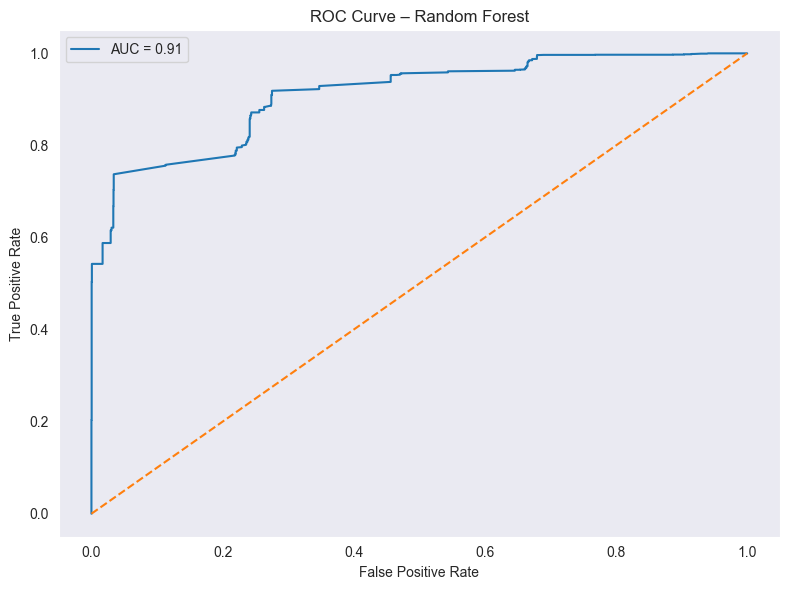

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

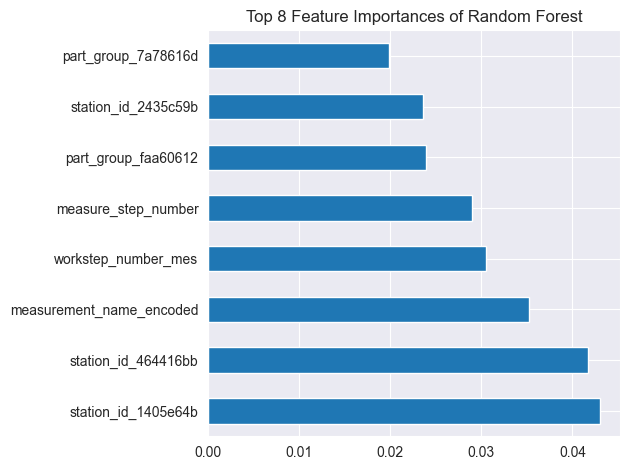

In [15]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(8).plot(kind='barh')
plt.title("Top 8 Feature Importances of Random Forest")
plt.tight_layout()
plt.show()